In [7]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import random
from scipy import stats

In [8]:
class Event:
    def __init__(self, time, event_type, customer=None, teller_id=None):
        self.time = time
        self.event_type = event_type  # 'arrival', 'departure', 'break_start', 'break_end'
        self.customer = customer
        self.teller_id = teller_id

In [9]:
class Customer:
    def __init__(self, arrival_time, is_vip=False, complexity=1):
        self.arrival_time = arrival_time
        self.is_vip = is_vip
        self.complexity = complexity  # 1: sederhana, 2: sedang, 3: kompleks
        self.service_start_time = None
        self.departure_time = None
        self.teller_id = None

In [10]:
class Teller:
    def __init__(self, id):
        self.id = id
        self.is_busy = False
        self.is_on_break = False
        self.busy_time = 0
        self.next_break = None

In [11]:
def bank_simulation(num_tellers, peak_hour_factor=1.0, sim_days=5, vip_ratio=0.2, break_freq=120):
    # Parameter
    np.random.seed(42)
    sim_time_per_day = 480  # 8 jam per hari
    total_sim_time = sim_time_per_day * sim_days
    current_time = 0
    event_list = []
    regular_queue = deque()
    vip_queue = deque()
    tellers = [Teller(i) for i in range(num_tellers)]
    waiting_times = {"vip": [], "regular": []}
    utilization_history = []
    queue_length_history = []

    # Distribusi waktu
    interarrival_time = lambda: np.random.exponential(5 / peak_hour_factor)
    service_time = lambda c: np.random.gamma(shape=c.complexity, scale=2) + 3  # Waktu layanan berdasarkan kompleksitas
    break_duration = lambda: np.random.uniform(10, 20)  # Istirahat 10-20 menit

    # Inisialisasi event pertama dan jadwal istirahat teller
    next_arrival = interarrival_time()
    event_list.append(Event(next_arrival, 'arrival'))
    for teller in tellers:
        teller.next_break = np.random.uniform(60, break_freq)
        event_list.append(Event(teller.next_break, 'break_start', teller_id=teller.id))

    # Main simulation loop
    while event_list and current_time < total_sim_time:
        event_list.sort(key=lambda x: x.time)
        event = event_list.pop(0)
        current_time = event.time

        if event.event_type == 'arrival':
            # Pelanggan baru tiba
            is_vip = random.random() < vip_ratio
            complexity = random.choices([1, 2, 3], weights=[0.5, 0.3, 0.2])[0]
            customer = Customer(current_time, is_vip, complexity)
            
            next_arrival = current_time + interarrival_time()
            if next_arrival < total_sim_time:
                event_list.append(Event(next_arrival, 'arrival'))

            # Cek teller yang tersedia
            teller_available = next((t for t in tellers if not t.is_busy and not t.is_on_break), None)
            if teller_available:
                teller_available.is_busy = True
                customer.service_start_time = current_time
                customer.teller_id = teller_available.id
                service_duration = service_time(customer)
                customer.departure_time = current_time + service_duration
                teller_available.busy_time += service_duration
                event_list.append(Event(customer.departure_time, 'departure', customer, teller_available.id))
            else:
                if customer.is_vip:
                    vip_queue.append(customer)
                else:
                    regular_queue.append(customer)

            # Catat panjang antrian
            queue_length_history.append((current_time, len(vip_queue) + len(regular_queue)))

        elif event.event_type == 'departure':
            # Teller selesai melayani
            customer = event.customer
            teller = tellers[event.teller_id]
            teller.is_busy = False
            waiting_time = customer.service_start_time - customer.arrival_time
            if customer.is_vip:
                waiting_times["vip"].append(waiting_time)
            else:
                waiting_times["regular"].append(waiting_time)

            # Layani pelanggan berikutnya
            teller_available = next((t for t in tellers if not t.is_busy and not t.is_on_break), None)
            if teller_available:
                next_customer = vip_queue.popleft() if vip_queue else (regular_queue.popleft() if regular_queue else None)
                if next_customer:
                    teller_available.is_busy = True
                    next_customer.service_start_time = current_time
                    next_customer.teller_id = teller_available.id
                    service_duration = service_time(next_customer)
                    next_customer.departure_time = current_time + service_duration
                    teller_available.busy_time += service_duration
                    event_list.append(Event(next_customer.departure_time, 'departure', next_customer, teller_available.id))

            # Catat utilisasi
            utilization = sum(1 for t in tellers if t.is_busy) / num_tellers
            utilization_history.append((current_time, utilization))

        elif event.event_type == 'break_start':
            # Teller mulai istirahat
            teller = tellers[event.teller_id]
            if not teller.is_busy:
                teller.is_on_break = True
                break_end_time = current_time + break_duration()
                event_list.append(Event(break_end_time, 'break_end', teller_id=teller.id))

        elif event.event_type == 'break_end':
            # Teller selesai istirahat
            teller = tellers[event.teller_id]
            teller.is_on_break = False
            if vip_queue or regular_queue:
                teller.is_busy = True
                next_customer = vip_queue.popleft() if vip_queue else regular_queue.popleft()
                next_customer.service_start_time = current_time
                next_customer.teller_id = teller.id
                service_duration = service_time(next_customer)
                next_customer.departure_time = current_time + service_duration
                teller.busy_time += service_duration
                event_list.append(Event(next_customer.departure_time, 'departure', next_customer, teller.id))

    # Statistik
    stats_dict = {
        "avg_wait_vip": np.mean(waiting_times["vip"]) if waiting_times["vip"] else 0,
        "avg_wait_regular": np.mean(waiting_times["regular"]) if waiting_times["regular"] else 0,
        "max_queue_length": max([ql[1] for ql in queue_length_history]) if queue_length_history else 0,
        "avg_utilization": np.mean([u[1] for u in utilization_history]) if utilization_history else 0,
        "teller_busy_times": [t.busy_time / total_sim_time for t in tellers]
    }

    return waiting_times, utilization_history, queue_length_history, stats_dict

In [12]:
# Jalankan simulasi untuk beberapa skenario
scenarios = [
    {"tellers": 2, "peak_factor": 1.0, "label": "2 Tellers, Normal"},
    {"tellers": 3, "peak_factor": 1.0, "label": "3 Tellers, Normal"},
    {"tellers": 2, "peak_factor": 2.0, "label": "2 Tellers, Peak"},
    {"tellers": 3, "peak_factor": 2.0, "label": "3 Tellers, Peak"}
]

results = []
for scenario in scenarios:
    wt, uh, qlh, stats = bank_simulation(
        num_tellers=scenario["tellers"],
        peak_hour_factor=scenario["peak_factor"]
    )
    results.append({
        "scenario": scenario["label"],
        "waiting_times": wt,
        "util_history": uh,
        "queue_length_history": qlh,
        "stats": stats
    })

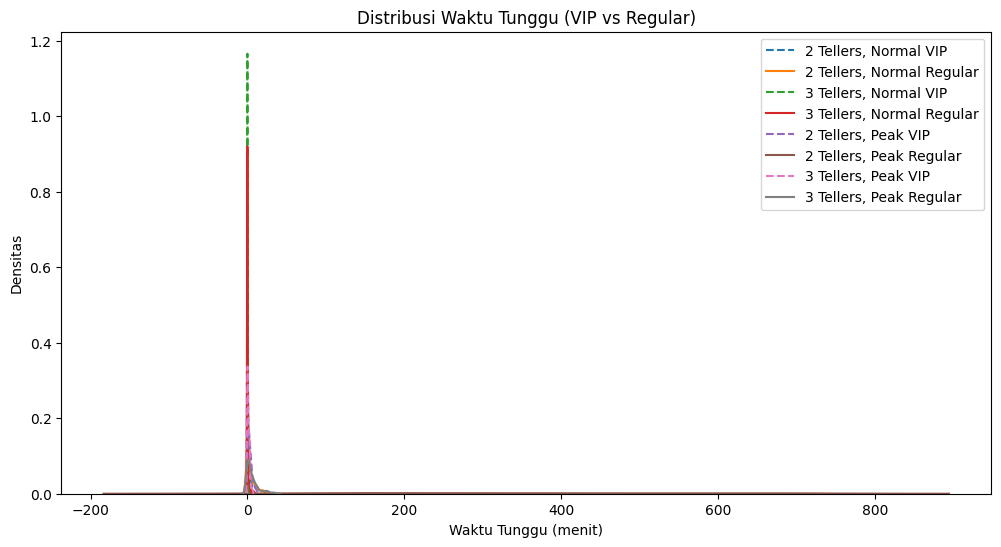

In [13]:
# Visualisasi 1: Distribusi Waktu Tunggu VIP vs Regular
plt.figure(figsize=(12, 6))
for res in results:
    sns.kdeplot(res["waiting_times"]["vip"], label=f"{res['scenario']} VIP", linestyle="--")
    sns.kdeplot(res["waiting_times"]["regular"], label=f"{res['scenario']} Regular")
plt.title("Distribusi Waktu Tunggu (VIP vs Regular)")
plt.xlabel("Waktu Tunggu (menit)")
plt.ylabel("Densitas")
plt.legend()
plt.show()

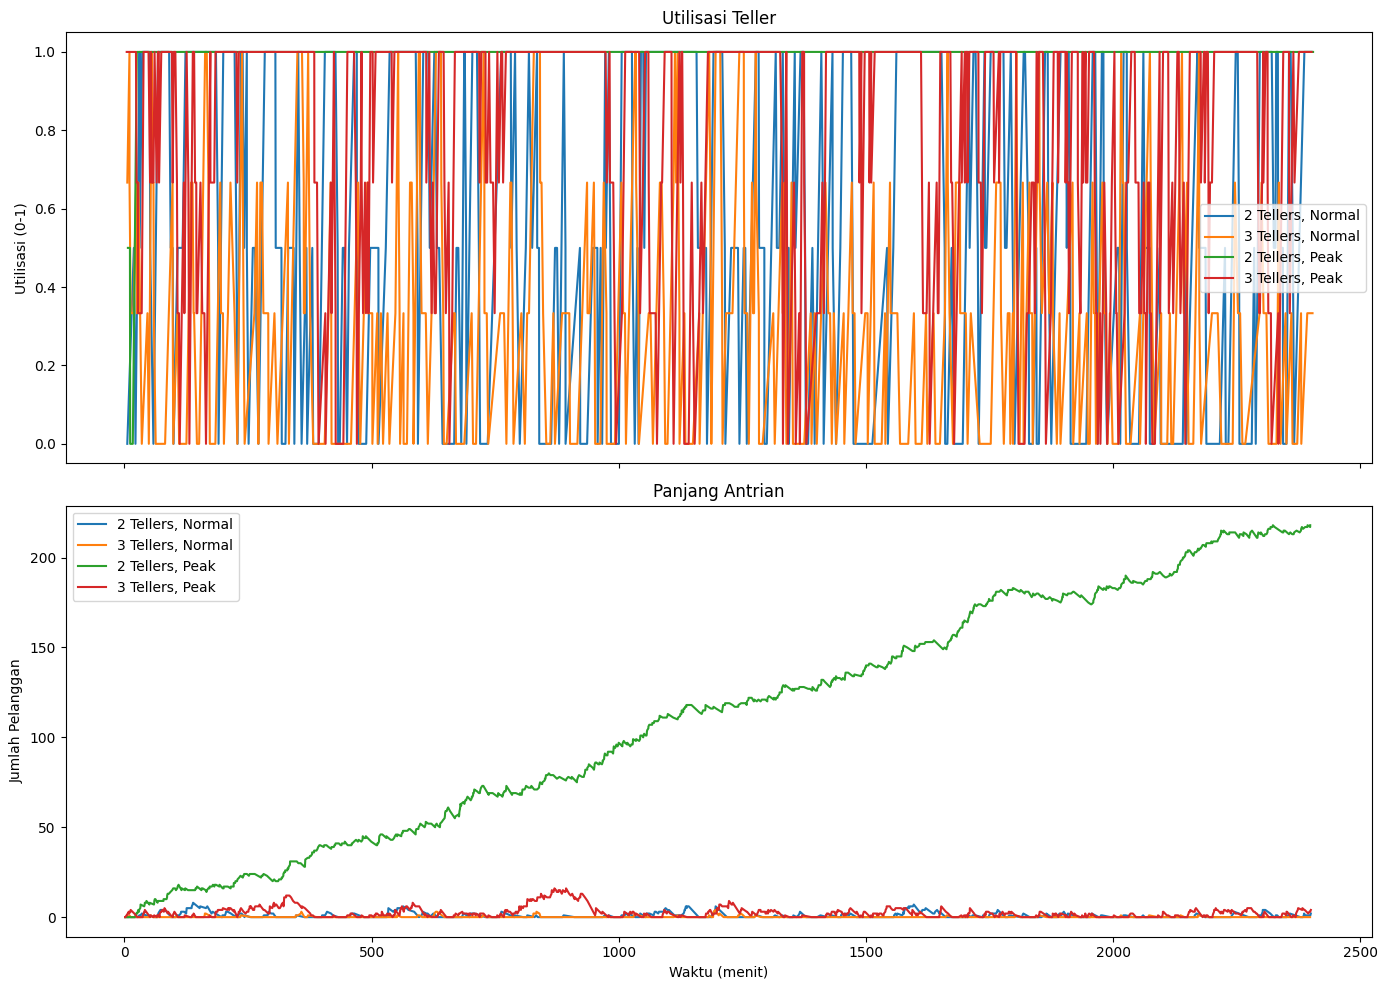

In [14]:
# Visualisasi 2: Utilisasi dan Panjang Antrian dari Waktu ke Waktu
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for res in results:
    times, utils = zip(*res["util_history"])
    axes[0].plot(times, utils, label=res["scenario"])
    times, qls = zip(*res["queue_length_history"])
    axes[1].plot(times, qls, label=res["scenario"])
axes[0].set_title("Utilisasi Teller")
axes[0].set_ylabel("Utilisasi (0-1)")
axes[0].legend()
axes[1].set_title("Panjang Antrian")
axes[1].set_xlabel("Waktu (menit)")
axes[1].set_ylabel("Jumlah Pelanggan")
axes[1].legend()
plt.tight_layout()
plt.show()

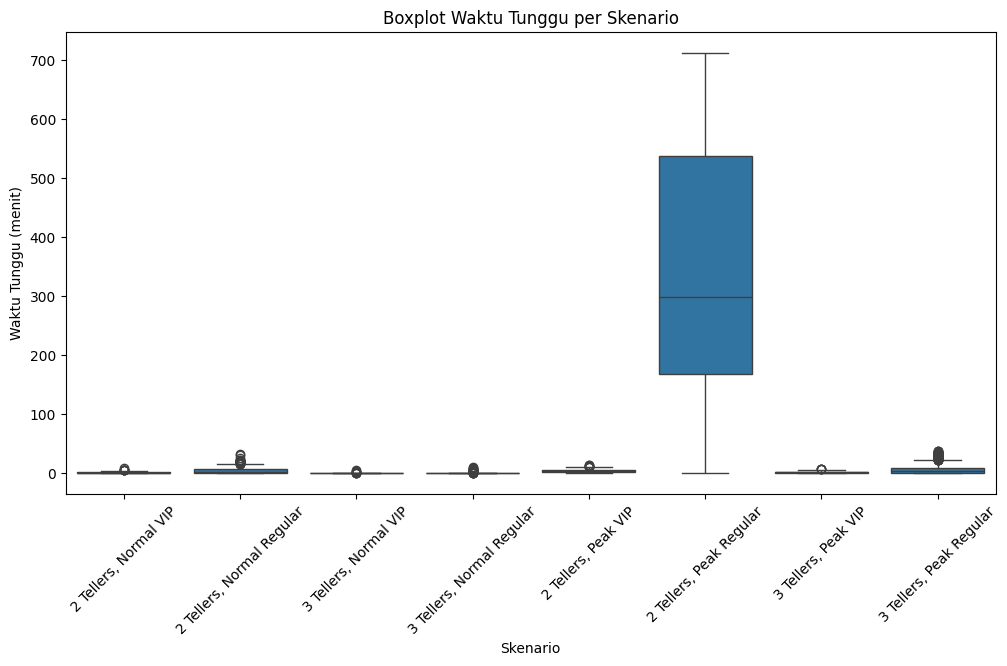

In [15]:
# Visualisasi 3: Boxplot Waktu Tunggu
plt.figure(figsize=(12, 6))
data = []
labels = []
for res in results:
    data.extend(res["waiting_times"]["vip"])
    labels.extend([f"{res['scenario']} VIP"] * len(res["waiting_times"]["vip"]))
    data.extend(res["waiting_times"]["regular"])
    labels.extend([f"{res['scenario']} Regular"] * len(res["waiting_times"]["regular"]))
sns.boxplot(x=labels, y=data)
plt.title("Boxplot Waktu Tunggu per Skenario")
plt.xlabel("Skenario")
plt.ylabel("Waktu Tunggu (menit)")
plt.xticks(rotation=45)
plt.show()

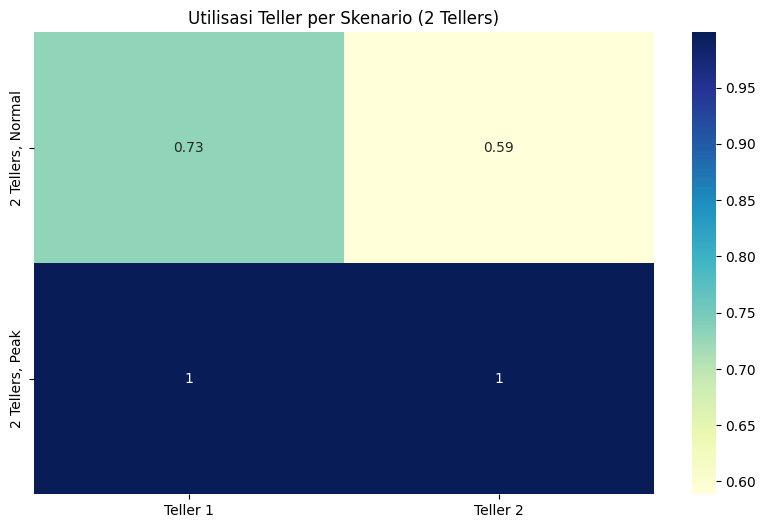

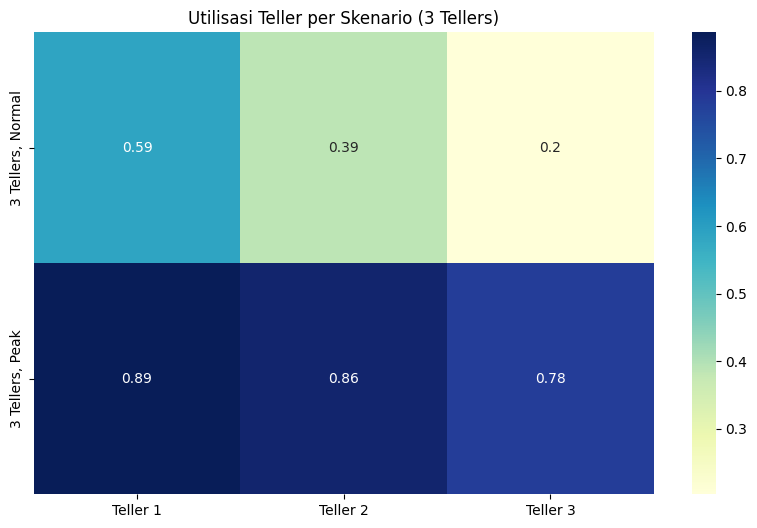

In [19]:
# Visualisasi 4: Heatmap Utilisasi Teller (Dipisah berdasarkan jumlah teller)
for num_tellers in set([len(res["stats"]["teller_busy_times"]) for res in results]):
    plt.figure(figsize=(10, 6))
    filtered_results = [res for res in results if len(res["stats"]["teller_busy_times"]) == num_tellers]
    teller_utils = np.array([res["stats"]["teller_busy_times"] for res in filtered_results])
    sns.heatmap(teller_utils, annot=True, cmap="YlGnBu", 
                xticklabels=[f"Teller {i+1}" for i in range(num_tellers)],
                yticklabels=[res["scenario"] for res in filtered_results])
    plt.title(f"Utilisasi Teller per Skenario ({num_tellers} Tellers)")
    plt.show()

In [18]:
# Tampilkan ringkasan statistik
print("Ringkasan Statistik Simulasi:")
for res in results:
    print(f"\n{res['scenario']}:")
    print(f"  Rata-rata Waktu Tunggu VIP: {res['stats']['avg_wait_vip']:.2f} menit")
    print(f"  Rata-rata Waktu Tunggu Regular: {res['stats']['avg_wait_regular']:.2f} menit")
    print(f"  Panjang Antrian Maksimum: {res['stats']['max_queue_length']}")
    print(f"  Rata-rata Utilisasi: {res['stats']['avg_utilization']:.2%}")
    print(f"  Utilisasi per Teller: {[f'{x:.2%}' for x in res['stats']['teller_busy_times']]}")

Ringkasan Statistik Simulasi:

2 Tellers, Normal:
  Rata-rata Waktu Tunggu VIP: 1.05 menit
  Rata-rata Waktu Tunggu Regular: 3.98 menit
  Panjang Antrian Maksimum: 8
  Rata-rata Utilisasi: 65.82%
  Utilisasi per Teller: ['73.03%', '58.86%']

3 Tellers, Normal:
  Rata-rata Waktu Tunggu VIP: 0.19 menit
  Rata-rata Waktu Tunggu Regular: 0.35 menit
  Panjang Antrian Maksimum: 4
  Rata-rata Utilisasi: 37.25%
  Utilisasi per Teller: ['58.74%', '38.70%', '20.28%']

2 Tellers, Peak:
  Rata-rata Waktu Tunggu VIP: 3.17 menit
  Rata-rata Waktu Tunggu Regular: 339.66 menit
  Panjang Antrian Maksimum: 218
  Rata-rata Utilisasi: 99.59%
  Utilisasi per Teller: ['99.93%', '99.85%']

3 Tellers, Peak:
  Rata-rata Waktu Tunggu VIP: 1.39 menit
  Rata-rata Waktu Tunggu Regular: 6.19 menit
  Panjang Antrian Maksimum: 16
  Rata-rata Utilisasi: 84.93%
  Utilisasi per Teller: ['88.68%', '85.59%', '78.24%']
